In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

In [2]:
from sklearn.datasets import make_classification
X,y = make_classification (n_samples=1000,
                          n_features=2,
                          n_informative=2,
                          n_redundant=0,
                          n_classes=2,
                          class_sep=2,
                          random_state=1)

In [3]:
pd.DataFrame(X).head()

,0,1
0,1.863411,0.087646
1,-1.530997,1.901182
2,-0.017224,-2.591112
3,-2.032039,-1.801162
4,4.620555,0.901124


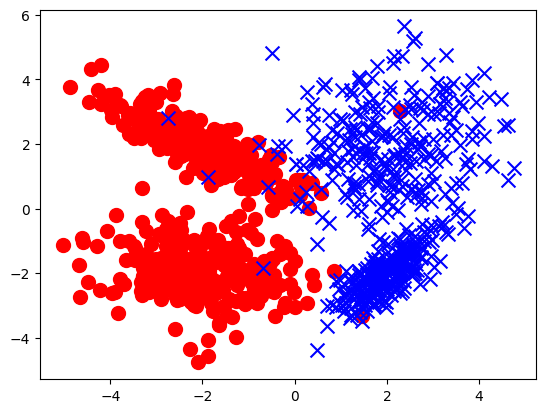

In [4]:
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
plt.show()

In [27]:
class SGD():
    def __init__(self, alpha=0.5, n_iters=1000):
        self.b = None
        self._alpha = alpha
        self._n_iters = n_iters

    def gradient_step(self, b, b_grad):
        return b - self._alpha * b_grad

    def optimize(self, X, y, start_b, n_iters):
        b = start_b.copy()
        for i in range(n_iters):
            b_grad = self.grad_func(X, y, b)
            b = self.gradient_step(b, b_grad)
        return b

    def fit(self, X, y):
        m = X.shape[1]
        start_b = np.ones(m)
        self.b = self.optimize(X, y, start_b, self._n_iters)

In [7]:
class LogReg(SGD):
    def sigmoid(self, X, b):        
        return 1. / (1. + np.exp(-X.dot(b)))

    def grad_func(self, X, y, b):
        n = X.shape[0]
        grad = 1. / n * X.transpose().dot(self.sigmoid(X, b) - y)
        return grad

    def predict_proba(self, X):
        return self.sigmoid(X, self.b)

    def predict(self, X):
        y_pred = self.predict_proba(X) > 0.5
        return y_pred

In [8]:
logreg = LogReg()

In [9]:
X = np.hstack([np.ones(X.shape[0])[:, np.newaxis], X])

In [10]:
logreg.fit(X, y)
y_pred = logreg.predict(X)

In [32]:
from sklearn.metrics import accuracy_score, f1_score
ac = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
print(f'accuracy = {ac:.4f} F1-score = {f1:.4f}')

accuracy = 0.9760 F1-score = 0.9761


In [13]:
y_pred_proba = logreg.predict_proba(X)

In [14]:
xx, yy = np.meshgrid(
    np.arange(X.min(axis=0)[1]-1, X.max(axis=0)[1]+1, 0.01), 
    np.arange(X.min(axis=0)[2]-1, X.max(axis=0)[2]+1, 0.01))
XX = np.array(list(zip(xx.ravel(), yy.ravel()))).reshape((-1, 2))
XX = np.array([(1, *xx) for xx in XX])

In [15]:
Z = logreg.predict_proba(XX)
Z = Z.reshape(xx.shape)

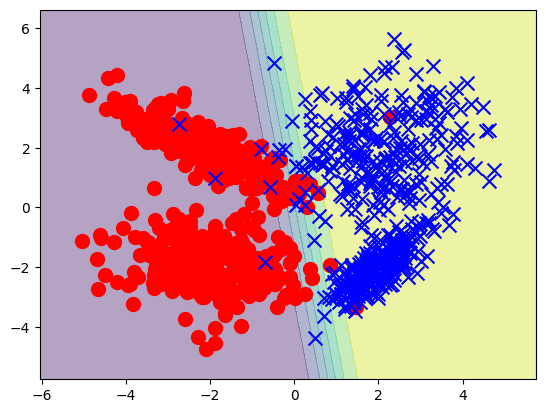

In [16]:
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:, 1][y==0], X[:, 2][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 1][y==1], X[:, 2][y==1], marker="x", c='b', s=100)

In [25]:
model = LogisticRegression()

In [26]:
model.fit(X, y)
y_pred_lr = model.predict(X)

## Практическая работа

### 1. Результаты работы модели библиотечной

In [33]:
from sklearn.metrics import accuracy_score, f1_score
ac_lr = accuracy_score(y, y_pred_lr)
f1_lr = f1_score(y, y_pred_lr)
print(f'accuracy = {ac:.4f} F1-score = {f1:.4f}')

accuracy = 0.9760 F1-score = 0.9761


In [35]:
ac, f1 #аналогично

(0.976, 0.9761431411530815)

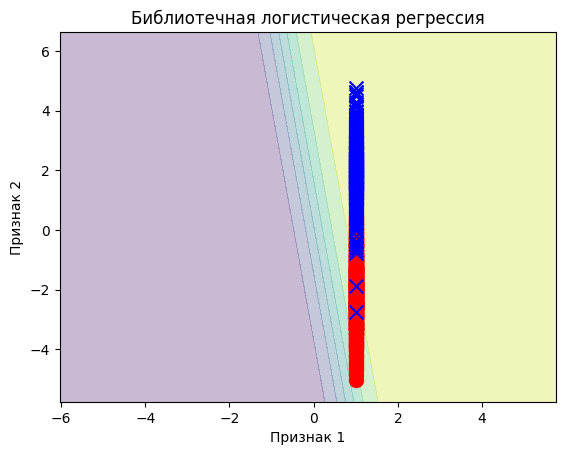

In [41]:
Z = model.predict_proba(XX)[:, 1]
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Библиотечная логистическая регрессия')
plt.show()

### 2. Работа модели с другой скоростью обучения

In [62]:
class SGD():
    def __init__(self, alpha, n_iters=1000):
        self.b = None
        self._alpha = alpha
        self._n_iters = n_iters
        self.losses = []

    def gradient_step(self, b, b_grad):
        return b - self._alpha * b_grad

    def optimize(self, X, y, start_b, n_iters):
        b = start_b.copy()
        losses = []
        for i in range(n_iters):
            b_grad = self.grad_func(X, y, b)
            b = self.gradient_step(b, b_grad)
            
        self.losses = losses
        return b

    def fit(self, X, y):
        m = X.shape[1]
        start_b = np.ones(m)
        self.b = self.optimize(X, y, start_b, self._n_iters)

class LogReg(SGD):
    def sigmoid(self, X, b):        
        return 1. / (1. + np.exp(-X.dot(b)))
    
    def grad_func(self, X, y, b):
        n = X.shape[0]
        grad = 1. / n * X.transpose().dot(self.sigmoid(X, b) - y)
        return grad
    
    def compute_loss(self, X, y, b):
        y_pred = self.sigmoid(X, b)
        loss = -np.mean(y * np.log(y_pred + 1e-10) + (1-y) * np.log(1-y_pred + 1e-10))
        return loss
    
    def optimize(self, X, y, start_b, n_iters):
        b = start_b.copy()
        losses = []
        for i in range(n_iters):
            b_grad = self.grad_func(X, y, b)
            b = self.gradient_step(b, b_grad)
            
            loss = self.compute_loss(X, y, b)
            losses.append(loss)
        
        self.losses = losses
        return b
    
    def predict_proba(self, X):
        return self.sigmoid(X, self.b)
    
    def predict(self, X):
        y_pred = self.predict_proba(X) > 0.5
        return y_pred

In [63]:
X_with_bias = np.hstack([np.ones(X.shape[0])[:, np.newaxis], X])

In [69]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]
results = {}

In [75]:
for alpha in alphas:
    model = LogReg(alpha=alpha, n_iters=200)
    model.fit(X_with_bias, y)

    y_pred = model.predict(X_with_bias)
    accuracy = np.mean(y_pred == y)
    results[alpha] = {
        'accuracy': accuracy,
        'final_loss': model.losses[-1],
        'losses': model.losses
    }
    print(f"При {alpha}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Final loss: {model.losses[-1]:.4f}")

    if np.isnan(model.losses[-1]) or np.isinf(model.losses[-1]):
        print(f"град расходится")
    elif model.losses[-1] > 1.0:
        print(f"потеря = {model.losses[-1]:.2f} (высокое значение)")

При 0.001:
  Accuracy: 0.7320
  Final loss: 0.5310
При 0.01:
  Accuracy: 0.9150
  Final loss: 0.2016
При 0.1:
  Accuracy: 0.9770
  Final loss: 0.0854
При 0.5:
  Accuracy: 0.9760
  Final loss: 0.0762
При 1.0:
  Accuracy: 0.9760
  Final loss: 0.0757
При 2.0:
  Accuracy: 0.9760
  Final loss: 0.0756
При 5.0:
  Accuracy: 0.9760
  Final loss: 0.0756
При 10.0:
  Accuracy: 0.9760
  Final loss: 0.0756
При 20.0:
  Accuracy: 0.9760
  Final loss: 0.0756
При 50.0:
  Accuracy: 0.9770
  Final loss: 0.1941
При 100.0:
  Accuracy: 0.9770
  Final loss: 0.3638


/var/folders/9t/l2gxj7bd2vldc_4gy7jxzmph0000gn/T/ipykernel_11184/882588474.py:28: RuntimeWarning: overflow encountered in exp
  return 1. / (1. + np.exp(-X.dot(b)))


### 3. Добавляем столбец единиц

In [76]:
class LogReg(SGD):
    def __init__(self, alpha=0.1, n_iters=1000):
        super().__init__(alpha, n_iters)
        self.b = None
        self._alpha = alpha
        self._n_iters = n_iters
        self.losses = []
    
    def sigmoid(self, X, b):        
        return 1. / (1. + np.exp(-X.dot(b)))
    
    def grad_func(self, X, y, b):
        n = X.shape[0]
        grad = 1. / n * X.transpose().dot(self.sigmoid(X, b) - y)
        return grad
    
    def compute_loss(self, X, y, b):
        y_pred = self.sigmoid(X, b)
        loss = -np.mean(y * np.log(y_pred + 1e-10) + (1-y) * np.log(1-y_pred + 1e-10))
        return loss
    
    def fit(self, X, y):
        X_with_bias = np.hstack([np.ones(X.shape[0])[:, np.newaxis], X])
        m = X_with_bias.shape[1]
        start_b = np.ones(m)
        self.b = self.optimize(X_with_bias, y, start_b, self._n_iters)
    
    def predict_proba(self, X):
        X_with_bias = np.hstack([np.ones(X.shape[0])[:, np.newaxis], X])
        return self.sigmoid(X_with_bias, self.b)
    
    def predict(self, X):
        y_pred = self.predict_proba(X) > 0.5
        return y_pred

model = LogReg(alpha=0.1, n_iters=1000)
model.fit(X, y)
y_pred = model.predict(X)

ac = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
print(f"Accuracy: {ac:.4f}, F1-score: {f1:.4f}")

Accuracy: 0.9760, F1-score: 0.9761


### 4. Рызные значения class_sep

In [79]:
class_sep_values = [0.5, 1.0, 2.0, 3.0]

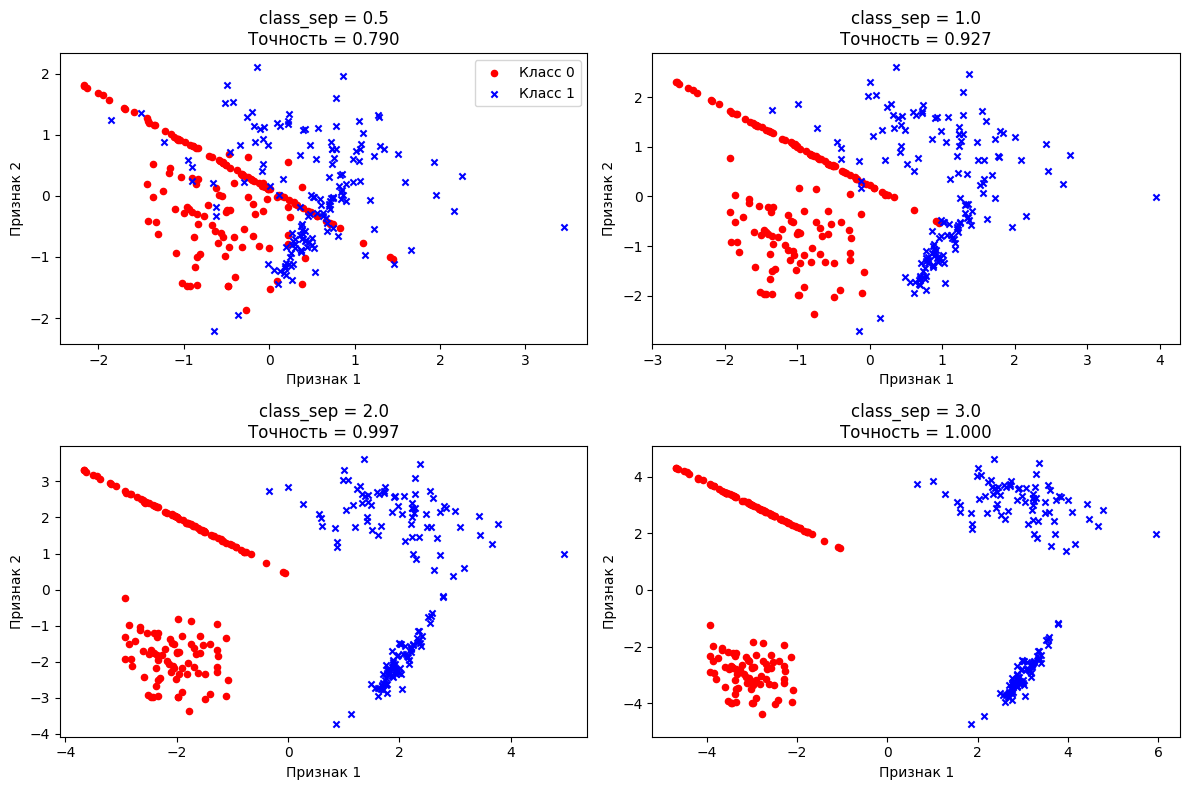

In [81]:
plt.figure(figsize=(12, 8))

for i, sep in enumerate(class_sep_values, 1):
    X, y = make_classification(n_samples=300, n_features=2, n_informative=2,
                               n_redundant=0, n_classes=2, class_sep=sep, random_state=42)
    
    model = LogisticRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    
    plt.subplot(2, 2, i)
    plt.scatter(X[:, 0][y==0], X[:, 1][y==0], c='red', marker='o', s=20, label='Класс 0')
    plt.scatter(X[:, 0][y==1], X[:, 1][y==1], c='blue', marker='x', s=20, label='Класс 1')
    plt.title(f'class_sep = {sep}\nТочность = {acc:.3f}')
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
    if i == 1:
        plt.legend()

plt.tight_layout()
plt.show()

In [82]:
for sep in class_sep_values:
    X, y = make_classification(n_samples=300, n_features=2, n_informative=2,
                               n_redundant=0, n_classes=2, class_sep=sep, random_state=42)
    model = LogisticRegression()
    model.fit(X, y)
    acc = accuracy_score(y, model.predict(X))
    print(f"class_sep = {sep}: точность = {acc:.3f}")

class_sep = 0.5: точность = 0.790
class_sep = 1.0: точность = 0.927
class_sep = 2.0: точность = 0.997
class_sep = 3.0: точность = 1.000


### 5. Большое число признаков

In [83]:
X_big, y_big = make_classification(n_samples=1000,
                                   n_features=20,
                                   n_informative=15,
                                   n_redundant=5,
                                   n_classes=2,
                                   class_sep=2,
                                   random_state=1)

model_big = LogReg(alpha=0.1, n_iters=500)
model_big.fit(X_big, y_big)

y_pred_big = model_big.predict(X_big)
acc_big = np.mean(y_pred_big == y_big)

print(f"\nТочность на датасете с 20 признаками: {acc_big:.4f}")


Точность на датасете с 20 признаками: 0.9820


### 6. Большое число классов

In [85]:
X, y = make_classification(n_samples=1000,
                          n_features=4,
                          n_informative=4,
                          n_redundant=0,
                          n_classes=5,
                          n_clusters_per_class=1,
                          class_sep=1.5,
                          random_state=42)

In [86]:
class OneVsAll:
    def __init__(self, model_class, **model_params):
        self.model_class = model_class
        self.model_params = model_params
        self.models = {}
        self.classes = None
    
    def fit(self, X, y):
        self.classes = np.unique(y)
        for class_label in self.classes:
            y_binary = (y == class_label).astype(int)
            model = self.model_class(**self.model_params)
            model.fit(X, y_binary)
            self.models[class_label] = model
    
    def predict(self, X):
        probas = np.zeros((X.shape[0], len(self.classes)))
        for i, class_label in enumerate(self.classes):
            probas[:, i] = self.models[class_label].predict_proba(X)
        return self.classes[np.argmax(probas, axis=1)]

In [92]:
model_own = OneVsAll(LogReg, alpha=0.1, n_iters=500)
model_own.fit(X, y)
y_pred_own = model_own.predict(X)
acc_own = accuracy_score(y, y_pred_own)

model_sk = OneVsRestClassifier(LogisticRegression(max_iter=1000))
model_sk.fit(X, y)
y_pred_sk = model_sk.predict(X)
acc_sk = accuracy_score(y, y_pred_sk)

model_multi = LogisticRegression(multi_class='multinomial', max_iter=1000)
model_multi.fit(X, y)
y_pred_multi = model_multi.predict(X)
acc_multi = accuracy_score(y, y_pred_multi)

/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [93]:
print(f"Своя реализация (OneVsAll): {acc_own:.4f}")
print(f"Sklearn OneVsRestClassifier: {acc_sk:.4f}")
print(f"Sklearn Multinomial: {acc_multi:.4f}")

Своя реализация (OneVsAll): 0.8560
Sklearn OneVsRestClassifier: 0.8630
Sklearn Multinomial: 0.8790


### 7. Вероятность принадлежности

In [99]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(multi_class='multinomial', max_iter=1000)
model.fit(X, y)

probas = model.predict_proba(X)

print("Вероятности для первых 5 объектов:")
print(probas[:5].round(3))

Вероятности для первых 5 объектов:
[[0.914 0.03  0.    0.055 0.   ]
 [0.007 0.991 0.    0.    0.002]
 [0.    0.014 0.006 0.015 0.964]
 [0.    0.    0.001 0.018 0.981]
 [0.    0.035 0.097 0.035 0.832]]


/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
